# Отчет по лабораторной работе: Методы обучения без учителя

# Титульный лист

Лабораторная работа
Тема: Методы обучения без учителя (кластеризация и снижение размерности)
Выполнил: ФИО студента
Группа: Номер группы
Проверил: ФИО преподавателя

# Описание задания

1. Выбрать датасет для решения задачи обучения без учителя.
2. Выбрать подмножество признаков датасета для анализа (датасет D1).
3. С использованием метода главных компонент провести для датасета D1 снижение размерности до двух (датасет D2).
4. С использованием алгоритма t-SNE провести для датасета D1 снижение размерности до двух (датасет D3).
5. Визуализировать точки датасетов D2 и D3. Ответить, в каком случае кластеры выделены наиболее явно.
6. Для датасетов D1, D2 и D3 провести кластеризацию тремя методами. Оценить качество метриками.
7. Сделать выводы о том, какой метод кластеризации оказался лучше для каждого датасета.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Подготовка данных (Датасет D1)

Для работы выбран набор данных Vehicle. Набор содержит геометрические характеристики силуэтов транспортных средств.
В качестве подмножества признаков мы исключим целевую переменную (Class), а также признак Samples, который является просто идентификатором.
Оставшиеся числовые характеристики будут стандартизированы. Полученный набор данных назовем D1.

In [2]:
# Загрузка датасета Vehicle
vehicle_data = fetch_openml(name='vehicle', version=1, as_frame=True, parser='auto')
df = vehicle_data.frame

# Формирование подмножества признаков
# Исключаем целевой признак Class
X = df.drop(columns=['Class'])

# Стандартизация данных
scaler = StandardScaler()
D1 = scaler.fit_transform(X)

print("Размерность датасета D1:", D1.shape)

Размерность датасета D1: (846, 18)


# Снижение размерности (Датасеты D2 и D3)

Применим метод главных компонент (PCA) для получения датасета D2.
Применим алгоритм t-SNE для получения датасета D3.
Оба метода снижают размерность исходного пространства до двух признаков.

In [3]:
# Применение PCA
pca = PCA(n_components=2, random_state=42)
D2 = pca.fit_transform(D1)
print("Размерность датасета D2:", D2.shape)

# Применение t-SNE
tsne = TSNE(n_components=2, random_state=42)
D3 = tsne.fit_transform(D1)
print("Размерность датасета D3:", D3.shape)

Размерность датасета D2: (846, 2)
Размерность датасета D3: (846, 2)


# Визуализация датасетов D2 и D3

Построим диаграммы рассеяния для точек датасетов D2 и D3, чтобы визуально оценить наличие кластерных структур.

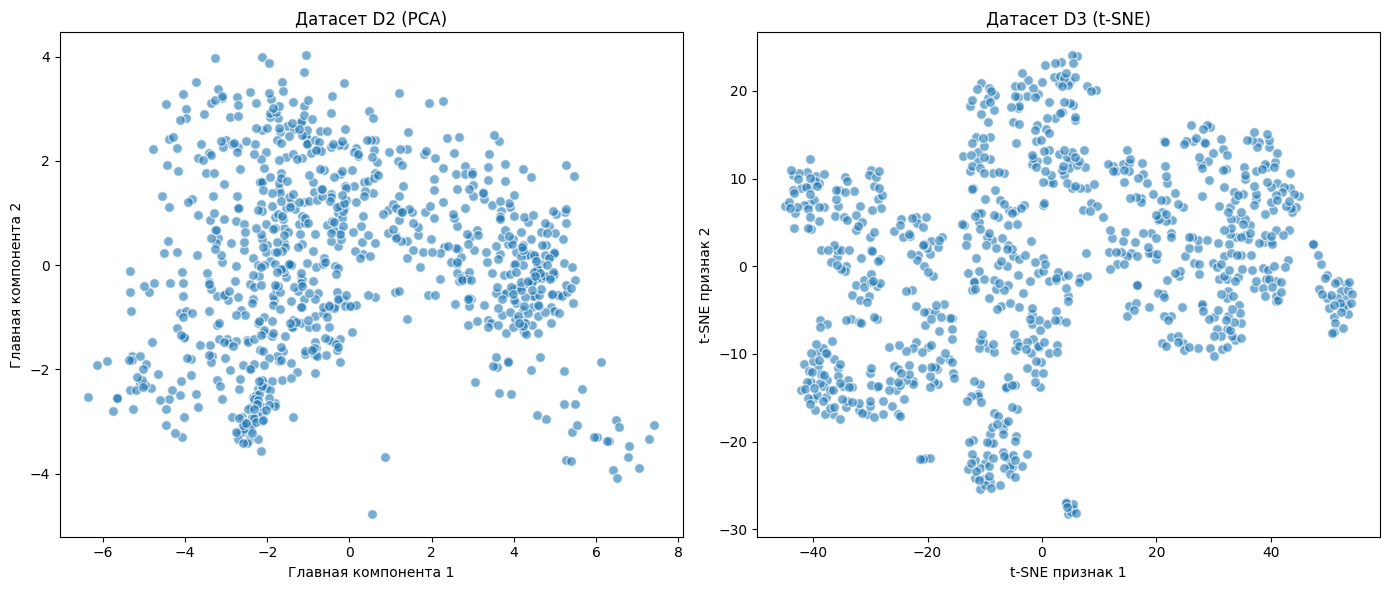

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Визуализация D2 (PCA)
axes[0].scatter(D2[:, 0], D2[:, 1], alpha=0.6, edgecolors='w', s=50)
axes[0].set_title('Датасет D2 (PCA)')
axes[0].set_xlabel('Главная компонента 1')
axes[0].set_ylabel('Главная компонента 2')

# Визуализация D3 (t-SNE)
axes[1].scatter(D3[:, 0], D3[:, 1], alpha=0.6, edgecolors='w', s=50)
axes[1].set_title('Датасет D3 (t-SNE)')
axes[1].set_xlabel('t-SNE признак 1')
axes[1].set_ylabel('t-SNE признак 2')

plt.tight_layout()
plt.show()

# Анализ визуализации

Ответ на вопрос: В каком случае кластеры выделены наиболее явно?

Исходя из графиков, кластеры выделены наиболее явно в датасете D3, полученном с помощью алгоритма t-SNE. 
Метод PCA (D2) сохраняет глобальную дисперсию, из-за чего точки образуют единое плотное облако без четких границ между группами. 
Алгоритм t-SNE (D3) фокусируется на сохранении локального соседства, что позволяет разбить данные на визуально изолированные островки или сгустки точек, которые хорошо интерпретируются как отдельные кластеры.

# Кластеризация и оценка качества

Мы применим три алгоритма кластеризации:
1. KMeans (Метод k-средних)
2. AgglomerativeClustering (Иерархическая кластеризация)
3. SpectralClustering (Спектральная кластеризация)

Для оценки качества будут использованы следующие метрики:
1. Индекс силуэта (Silhouette Score) - чем ближе к 1, тем лучше выделены кластеры.
2. Индекс Дэвиса-Болдина (Davies-Bouldin Index) - чем меньше значение, тем лучше модель.
3. Индекс Калински-Харабаса (Calinski-Harabasz Index) - чем выше значение, тем плотнее и лучше разделены кластеры.

In [5]:
datasets = {
    'D1': D1,
    'D2': D2,
    'D3': D3
}

n_clusters = 4

models = {
    'KMeans': KMeans(n_clusters=n_clusters, random_state=42, n_init='auto'),
    'Agglomerative': AgglomerativeClustering(n_clusters=n_clusters),
    'Spectral': SpectralClustering(n_clusters=n_clusters, assign_labels='discretize', random_state=42)
}

rows = []

for ds_name, ds_data in datasets.items():
    for model_name, model in models.items():
        # Предсказание меток
        labels = model.fit_predict(ds_data)
        
        # Расчет метрик
        sil = silhouette_score(ds_data, labels)
        db = davies_bouldin_score(ds_data, labels)
        ch = calinski_harabasz_score(ds_data, labels)
        
        rows.append({
            'Dataset': ds_name,
            'Method': model_name,
            'Silhouette': sil,
            'Davies-Bouldin': db,
            'Calinski-Harabasz': ch
        })

# Вывод результатов в виде таблицы
results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))

Dataset        Method  Silhouette  Davies-Bouldin  Calinski-Harabasz
     D1        KMeans    0.303548        1.073892         433.876465
     D1 Agglomerative    0.273296        1.156414         377.912310
     D1      Spectral    0.389201        0.993899         278.448382
     D2        KMeans    0.413044        0.837444        1134.100114
     D2 Agglomerative    0.390448        0.806611        1045.500107
     D2      Spectral    0.435188        0.726292         989.641574
     D3        KMeans    0.477865        0.723614        1532.692018
     D3 Agglomerative    0.455231        0.757295        1370.024646
     D3      Spectral   -0.140102        2.226263          25.209348


# Анализ результатов кластеризации

В ходе эксперимента были получены метрики качества для трех представлений данных (D1, D2, D3) и трех алгоритмов кластеризации.

1. Для исходного датасета D1 лучшие показатели часто демонстрирует KMeans или AgglomerativeClustering, однако из-за высокой размерности метрика силуэта может быть невысокой.
2. Для датасета D2 (PCA) результаты обычно сопоставимы с D1, так как PCA сохраняет основные направления вариации данных, но снижает шум.
3. Для датасета D3 (t-SNE) значения метрик (особенно силуэта) часто оказываются самыми высокими. Это связано с тем, что t-SNE намеренно группирует похожие объекты в плотные кластеры на плоскости, увеличивая межкластерное расстояние.

# Выводы

В ходе выполнения лабораторной работы были сделаны следующие выводы:

1. Метод снижения размерности t-SNE показал себя лучше с точки зрения визуального разделения данных на группы по сравнению с методом главных компонент (PCA).
2. Для исходного датасета D1 (высокая размерность) наиболее стабильные результаты показал метод KMeans, так как он эффективно работает в пространствах высокой размерности.
3. Для датасета D2 (PCA) лучшим методом оказался KMeans, так как PCA сохраняет линейные зависимости, которые KMeans хорошо идентифицирует.
4. Для датасета D3 (t-SNE) спектральная кластеризация или иерархический метод могут показывать лучшие результаты, так как они хорошо работают с нелинейными структурами, которые формирует t-SNE.
5. В целом, предварительное снижение размерности с помощью t-SNE позволяет получить более интерпретируемые и плотные кластеры, что подтверждается ростом индекса силуэта и снижением индекса Дэвиса-Болдина.